In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [2]:
import sys
sys.path.append('/home/bioit/tjung/Desktop/wormhole_ot')

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
import anndata
import umap

from wassersteinwormhole_ import SpatialWormhole, _utils_Processing

In [4]:
def estimate_k_neighbors(spatial_data, radius, spatial_key='spatial'):
    """
    Compute neighbors for each cell that are within the given radius (Euclidean distance) and return median of cell counts per point clouds as k neighbors
    """
    radiusGraph = sklearn.neighbors.radius_neighbors_graph(spatial_data.obsm[spatial_key], p=2, radius=radius, mode='connectivity', n_jobs=-1).tocsr()
    niche_indices = np.split(radiusGraph.indices, radiusGraph.indptr[1:-1])
    mean_cell_counts = np.median([len(indices) for indices in niche_indices]) # cells/um^2
    return int(mean_cell_counts), [len(indices) for indices in niche_indices]

In [ ]:
import umap
import numpy as np
import pandas as pd
import scipy.stats

import matplotlib
import matplotlib.pyplot as plt
import colorcet
import seaborn as sns


import sklearn.metrics
import sklearn.neural_network
import sklearn.neighbors
import skimage.filters

In [5]:
# Only cells with gene counts in range of [19, 1095] is retained
data = '/data/tjung/spatial_pred/WSI2RNA/notebooks/VisiumHD_prad_seg.h5ad'
adata = anndata.read_h5ad(data)

In [7]:
# Load signatures
oncotype_dx = ['TPX2', 'BGN', 'COL1A1', 'SFRP4', 'FLNC', 'SRD5A2', 'GSN', 'TPM2', 'FAM13C', 'AZGP1', 'KLK2']
decipher = ['TNFRSF19', 'MYBPC1', 'NUSAP1', 'ZWILCH', 'IQGAP3', 'UBE2C', 'CAMK2N1', 'EPPK1', 'THBS2', 'LASP1', 'RABGAP1', 'NFIB', 'PBX1',  'PCDH7']
prostadiag = ['REPS2', 'ACADL', 'SLC15A2', 'SLC22A3', 'FMOD', 'HGD', 'CD38', 'AFF3', 'GREB1', 'ANPEP', 'NCAPD3', 'CHRNA2', 'PAK1IP1', "KHDRBS3", 'MGP', 'COL1A2', 'MOXD1', 'SFRP2', 'FRZB', 'SPARC', 'CDH11', 'SULF1', 'COL3A1', 'MS4A6A', 'COMP', 'COL10A1', 'NOX4', 'CXCL14', 'THBS2', 'VCAN', 'COL8A1', 'SFRP4', 'ASPN', 'COL1A1']
combined_signature = ['TOP2A', 'CENPF', 'UBE2C', 'NUSAP1', 'TPX2', 'VCAN', 'SFRP4', 'THBS2', 'COL10A1', 'COL11A1']

pam50_genes = ['ACTR3B', 'ANLN', 'BAG1', 'BCL2', 'BIRC5', 'BLVRA', 'CCNB1',
       'CCNE1', 'CDC20', 'CDC6', 'CDCA1', 'CDH3', 'CENPF', 'CEP55',
       'CXXC5', 'EGFR', 'ERBB2', 'ESR1', 'EXO1', 'FGFR4', 'FOXA1',
       'FOXC1', 'GPR160', 'GRB7', 'KIF2C', 'KNTC2', 'KRT14', 'KRT17',
       'KRT5', 'MAPT', 'MDM2', 'MELK', 'MIA', 'MKI67', 'MLPH', 'MMP11',
       'MYBL2', 'MYC', 'NAT1', 'ORC6L', 'PGR', 'PHGDH', 'PTTG1', 'RRM2',
       'SFRP1', 'SLC39A6', 'TMEM45B', 'TYMS', 'UBE2C', 'UBE2T']

In [15]:
# Genes that are not included in three commerical signatures
print([i for i in combined_signature if i not in oncotype_dx + decipher + prostadiag])
signatures = [i for i in list(set(oncotype_dx + decipher + prostadiag + combined_signature)) if i in adata.var_names] # 59 genes

['TOP2A', 'CENPF', 'COL11A1']


In [57]:
# min-max normalization
adata_scaled = adata[:,signatures].copy()
adata_scaled.X = _utils_Processing.MaxMinScale(adata_scaled.X.toarray())

In [60]:
radius = 50 # um
mmp = 0.2738 # um/px
k_neighbors, cell_density = estimate_k_neighbors(adata, radius=radius/mmp, spatial_key='spatial')

array([[<Axes: title={'center': 'Cell counts per point cloud'}>]],
      dtype=object)

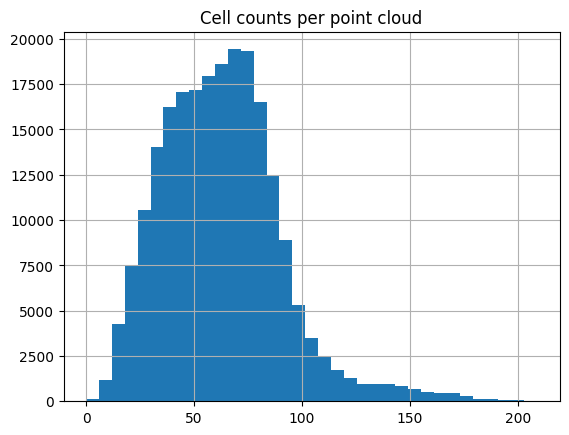

In [61]:
pd.DataFrame({'Cell counts per point cloud':cell_density}).hist(bins=35)

In [62]:
WormholeModel = SpatialWormhole(adata_scaled, k_neighbours=k_neighbors)

Pre-computing neighbor indices and caching expression data...
Largest niche found has 61 neighbors. This will be the padding size.
Decoder generating point-clouds of size:  61
Calculating OT scale value from a sample of niches...


Calculating max of max distances (metric: squared Euclidean): 100%|██████████| 100/100 [00:00<00:00, 354.84it/s]


Using OT scale value of 1.13e+01
Automatically setting num_sinkhorn_iter by testing OT function...
Preparing batch of 100 pairs for S2 convergence check...
Running S2 solver for 5000 iterations on 100 pairs...
95% convergence reached at approx 100 iterations.
Setting num_sinkhorn_iter to 100


In [63]:
%%time
WormholeModel.train()

Starting training loop using adam...


 enc_loss: 6.008e-05 dec_loss: 1.392e-02 enc_corr: 0.944: 100%|██████████| 10000/10000 [08:24<00:00, 19.81it/s]

CPU times: user 4min 33s, sys: 24.2 s, total: 4min 58s
Wall time: 8min 25s


In [64]:
cell_indices = [i for i in range(0, adata_scaled.shape[0])]

In [65]:
train_encodings = WormholeModel.encode(cell_indices=cell_indices, from_test_set=False)

Encoding: 100%|██████████| 868/868 [01:23<00:00, 10.38it/s]


In [66]:
%%time
fit = umap.UMAP(
    n_neighbors = 30,
    min_dist = 0.01,
    n_components = 2,
)

umap_train = fit.fit_transform(train_encodings)

CPU times: user 39min 17s, sys: 4.57 s, total: 39min 21s
Wall time: 1min 21s


In [73]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)   # choose how many PCs you want
train_encodings_pca = pca.fit_transform(train_encodings)

In [74]:
%%time
fit = umap.UMAP(
    n_neighbors = 30,
    min_dist = 0.01,
    n_components = 2,
)

umap_train_pca = fit.fit_transform(train_encodings_pca)

CPU times: user 38min 38s, sys: 7.01 s, total: 38min 45s
Wall time: 1min 20s


In [ ]:
def diffusion_maps_from_kernel(
    kernel: csr_matrix, n_components: int = 10, seed: Union[int, None] = 0
) -> Dict[str, Union[csr_matrix, pd.DataFrame, pd.Series]]:
    """
    Compute the diffusion map given a kernel matrix.

    Parameters
    ----------
    kernel : csr_matrix
        Precomputed kernel matrix.
    n_components : int
        Number of diffusion components to compute. Default is 10.
    seed : Union[int, None]
        Seed for random initialization. Default is 0.

    Returns
    -------
    Dict[str, Union[csr_matrix, pd.DataFrame, pd.Series]]
        Dictionary containing:
        - T: Transition matrix (csr_matrix)
        - EigenVectors: Diffusion components (pd.DataFrame)
        - EigenValues: Corresponding eigenvalues (pd.Series)
    """
    N = kernel.shape[0]
    D = np.ravel(kernel.sum(axis=1))
    D[D != 0] = 1 / D[D != 0]
    T = csr_matrix((D, (range(N), range(N))), shape=[N, N]).dot(kernel)

    np.random.seed(seed)
    v0 = np.random.rand(min(T.shape))
    D, V = eigs(T, n_components, tol=1e-4, maxiter=1000, v0=v0)

    D = np.real(D)
    V = np.real(V)
    inds = np.argsort(D)[::-1]
    D = D[inds]
    V = V[:, inds]

    for i in range(V.shape[1]):
        V[:, i] = V[:, i] / np.linalg.norm(V[:, i])

    return {"T": T, "EigenVectors": pd.DataFrame(V), "EigenValues": pd.Series(D)}


def run_diffusion_maps(
    data: Union[pd.DataFrame, AnnData],
    n_components: int = 10,
    knn: int = 30,
    alpha: float = 0,
    seed: Union[int, None] = 0,
    kernel_backend: str = "scanpy",
    pca_key: str = "X_pca",
    kernel_key: str = "DM_Kernel",
    sim_key: str = "DM_Similarity",
    eigval_key: str = "DM_EigenValues",
    eigvec_key: str = "DM_EigenVectors",
) -> Dict[str, Union[csr_matrix, pd.DataFrame, pd.Series]]:
    """
    Run Diffusion maps using the adaptive anisotropic kernel.

    Parameters
    ----------
    data : Union[pd.DataFrame, AnnData]
        PCA projections of the data or adjacency matrix.
        If AnnData is passed, its obsm[pca_key] is used and the result is written to
        its obsp[kernel_key], obsm[eigvec_key], and uns[eigval_key].
    n_components : int, optional
        Number of diffusion components. Default is 10.
    knn : int, optional
        Number of nearest neighbors for graph construction. Default is 30.
    alpha : float, optional
        Normalization parameter for the diffusion operator. Default is 0.
    seed : Union[int, None], optional
        Numpy random seed, randomized if None, set to an arbitrary integer for reproducibility.
        Default is 0.
    kernel_backend : str, optional
        Kernel construction backend: "scanpy" (parity with prior behavior; approximate
        kNN via scanpy/UMAP) or "sklearn" (exact kNN; may drift and can be slower on
        large/high-dimensional data). Defaults to "scanpy".
    pca_key : str, optional
        Key to retrieve PCA projections from data if it is a AnnData object. Default is 'X_pca'.
    kernel_key : str, optional
        Key to store the kernel in obsp of data if it is a AnnData object. Default is 'DM_Kernel'.
    sim_key : str, optional
        Key to store the similarity in obsp of data if it is a AnnData object. Default is 'DM_Similarity'.
    eigval_key : str, optional
        Key to store the EigenValues in uns of data if it is a AnnData object. Default is 'DM_EigenValues'.
    eigvec_key : str, optional
        Key to store the EigenVectors in obsm of data if it is a AnnData object. Default is 'DM_EigenVectors'.

    Returns
    -------
    Dict[str, Union[csr_matrix, pd.DataFrame, pd.Series]]
        Dictionary containing:
        - kernel: Computed kernel matrix
        - T: Transition matrix
        - EigenVectors: Diffusion components
        - EigenValues: Corresponding eigenvalues
        If AnnData is passed as data, these results are also written to the input object.
    """

    if isinstance(data, AnnData):
        data_df = pd.DataFrame(data.obsm[pca_key], index=data.obs_names)
    else:
        data_df = data

    if not isinstance(data_df, pd.DataFrame) and not issparse(data_df):
        raise ValueError("'data_df' should be a pd.DataFrame or AnnData")

    if not issparse(data_df):
        kernel = compute_kernel(data_df, knn, alpha, backend=kernel_backend)
    else:
        warn(
            "'data' is a sparse matrix and will be interpreted as kernel. "
            "To avoid this warning compute diffusion maps from a precompued kernel using "
            "palantir.utils.diffusion_maps_from_kernel()."
        )
        kernel = data_df

    res = diffusion_maps_from_kernel(kernel, n_components, seed)

    res["kernel"] = kernel
    if not issparse(data_df):
        res["EigenVectors"].index = data_df.index

    if isinstance(data, AnnData):
        data.obsp[kernel_key] = res["kernel"]
        data.obsp[sim_key] = res["T"]
        data.obsm[eigvec_key] = res["EigenVectors"].values
        data.uns[eigval_key] = res["EigenValues"].values

    return res


Text(0.5, 1.0, 'PCA')

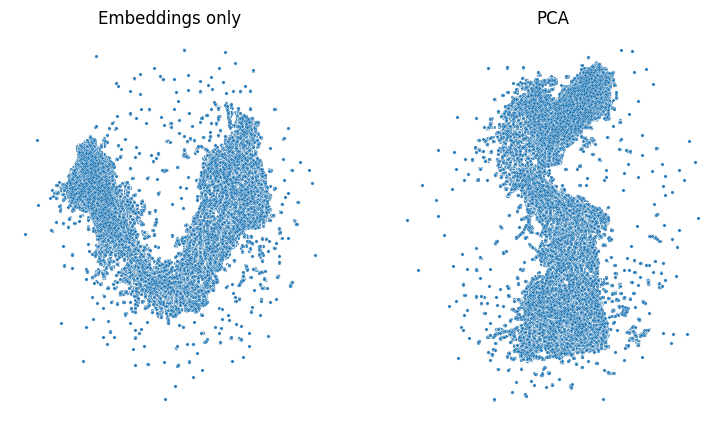

In [80]:
plt.figure(figsize=(14,5))
plt.subplot(131)
sns.scatterplot(x = umap_train[:, 0],
                y = umap_train[:, 1], legend = True,
                s = 5)
plt.axis('off')
plt.title("Embeddings only")

plt.subplot(132)
sns.scatterplot(x = umap_train_pca[:, 0],
                y = umap_train_pca[:, 1], legend = True,
                s = 5)

plt.axis('off')
plt.title("PCA")